### Note

The files required to generate Fig. 2c and d are too large to be hosted on GitHub and therefore exceed the repository size limit. However, all required files can be reproduced by following the methods described in the paper. The following inputs need to be prepared:

1. **Human and mouse GTF files**, including annotations for different RDH families as well as other genes.

2. **deepTools matrices** generated using `computeMatrix reference-point`. An example command is shown below:

   ```bash
   computeMatrix reference-point --referencePoint TSS \
       -S \
       /public4/home/jiangzj/data/tmp_node80/APOBEC3B-GSE148581-MCF10A/hg38.IP-GFP_DMSO.DOX+vsDOX-.SES_log2.bw \
       -R "${gtfs[@]}" \
       -a 3000 -b 3000 -bs 100 --numberOfProcessors 16 \
       -out result_reference_point/histone.hg38.IP-GFP_DMSO.DOX+vsDOX-.rpkm_log2ratio.3000.out.gz \
       --outFileNameMatrix result_reference_point/histone.hg38.IP-GFP_DMSO.DOX+vsDOX-.rpkm_log2ratio.3000.tab \
       --outFileSortedRegions result_reference_point/histone.hg38.IP-GFP_DMSO.DOX+vsDOX-.rpkm_log2ratio.3000.bed
    ```

The `-out` file should then be further processed to split the matrix according to the corresponding GTF files.

3. **BigWig tracks**, including mouse RPA (RPKM) and human A3B (−log10 *P*).

In [1]:
import numpy as np
import os
import sys
import pandas as pd
from matplotlib.patches import Rectangle
import pandas as pd
import matplotlib.patches as mpatches
import pyBigWig
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
def plot_deeptoolsop_subplot_reference_point(ax, variant_matrx_file_lst, genegroup_name_lst, title, ylabel, inverty=True, linewidth=1, ci_plot=False):

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    plot_idx = 0

    for _, (matrix, genegroup) in enumerate(zip([np.loadtxt(i) for i in variant_matrx_file_lst], genegroup_name_lst)):
        
        df = pd.DataFrame(matrix)
        means = df.mean()
        stds = df.std()
        n = len(df)
        ci_lower = means - (1.96 * (stds / np.sqrt(n)))
        ci_upper = means + (1.96 * (stds / np.sqrt(n)))
        color = colors[plot_idx]
        ax.plot(means.index, means.values, label=genegroup, linewidth=linewidth, color=color)
        if ci_plot:
            ax.fill_between(means.index, ci_lower, ci_upper, alpha=0.2, color=color)
        plot_idx += 1
        
    x_positions = np.linspace(0, len(means) - 1, 3)
    x_labels = ["-3.0", "TSS", "3.0kb"]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    
    if inverty:
        ax.invert_yaxis()

In [3]:
# Replace path according to your own directory structure
spe_basic_param = {
    "human": {
        "base path": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/matrix_format",
        "prefix": [
            "gencode.v44.basic.annotation.Ensembl_canonical.autosomes.gtf",
            "hg38_histone_cluster.gtf",
        ],
    },
    "mouse": {
        "base path": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/matrix_format",
        "prefix": [
            "mm10.ucsc_database.ncbi_refseq.autosome_pc.longest_cds.gtf",
            "mm10_histone_cluster.gtf",
        ],
    },
}

# Replace path according to your own directory structure
config_dict = {
    "human": {
        "H1": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_histone_cluster.H1.gtf",
        "H2A": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_histone_cluster.H2A.gtf",
        "H2B": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_histone_cluster.H2B.gtf",
        "H3": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_histone_cluster.H3.gtf",
        "H4": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_histone_cluster.H4.gtf",
        "non-histone": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/human/hg38_nonhistone.gtf",
    },
    "mouse": {
        "H1": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_histone_cluster.H1.gtf",
        "H2A": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_histone_cluster.H2A.gtf",
        "H2B": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_histone_cluster.H2B.gtf",
        "H3": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_histone_cluster.H3.gtf",
        "H4": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_histone_cluster.H4.gtf",
        "non-histone": "/public4/home/jiangzj/analysis/mtr/histone_mutation_explore/all_species_summary/deeptools/mouse/mm10_nonhistone.gtf",
    },
}

# Replace path according to your own directory structure
color_dict = {
    "H1": "#E69F00",
    "H2A": "#56B4E9",
    "H2B": "#009E73",
    "H3": "#0072B2",
    "H4": "#CC79A7",
    "non-histone": "black",
}

Plot function

In [4]:
def plot_bigwig_track(
        chrom: str,
        start: int,
        end: int,
        binsize: int,
        bigwig_file: str,
        ax,
        smoothing: bool = False,
        smoothing_window: int = 5,
        linewidth: float = 0.7,
        color='black',
        reverse=False,
        fill: bool = True,
        scale_factor: float = 1.0,
):
    
    bw = pyBigWig.open(bigwig_file)
    values = bw.values(chrom, start, end)
    positions = np.arange(start, end)

    bin_value = []
    bin_position = []

    for ss in range(0, len(values), binsize):
        es = ss + binsize
        bin_value.append(np.nanmean(values[ss:es]))
        bin_position.append(np.mean(positions[ss:es]))
    if smoothing:
        bin_value = np.convolve(bin_value, np.ones(smoothing_window) / smoothing_window, mode='same')

    # Fill the area under the curve
    if reverse:
        bin_value = -np.array(bin_value)

    bin_value = np.array(bin_value)
    bin_position = np.array(bin_position)

    if fill == True:
        ax.fill_between(bin_position, bin_value * scale_factor, color=color, linewidth=linewidth)
    else:
        ax.plot(bin_position, bin_value * scale_factor, linewidth=linewidth, color=color)

    interval_len = end - start
    ax.set_xlim(start - interval_len*0.01, end + interval_len*0.01)

In [5]:
def plot_gtf(ax, gtf_file, chrom, ss, es, gene_id=None, height=0.6,
             exon_color='#005a9e', utr_color='#005a9e', intron_color='#005a9e',
             utr_rel_height=0.6, arrow_head_length_propor=0.001,
             arrow_interval=2, min_gene_fraction_for_arrows=0.01,
             feature_order=('exon', 'CDS', 'five_prime_utr', 'three_prime_utr')):

    # Load and parse GTF efficiently
    try:
        cols = ['chrom', 'source', 'feature', 'start', 'end', 'score', 
               'strand', 'frame', 'attribute']
        df = pd.read_csv(gtf_file, sep='\t', comment='#', header=None, 
                         names=cols, low_memory=False)
        # Extract attributes more efficiently
        df['transcript_id'] = df['attribute'].str.extract('transcript_id "([^"]+)"')
    
    except Exception as e:
        print(f"Error parsing GTF: {e}", file=sys.stderr)
        return ax

    # Filter to relevant region
    region_mask = (df['chrom'] == chrom) & (df['end'] >= ss) & (df['start'] <= es)
    if gene_id:
        region_mask &= (df['gene_id'] == gene_id)
    df = df[region_mask].copy()
    
    if df.empty:
        print(f"No features found in region {chrom}:{ss}-{es}{' for gene ' + gene_id if gene_id else ''}", 
              file=sys.stderr)
        return ax

    # Process transcripts
    transcripts = {}
    for tx_id, tx_df in df.groupby('transcript_id'):
        if tx_id is None or tx_df.empty:
            continue
            
        # Get transcript metadata
        strand = tx_df['strand'].iloc[0]
        exons = []
        utrs = []
        
        # Process features with priority
        for feature in feature_order:
            f_df = tx_df[tx_df['feature'] == feature]
            for _, row in f_df.iterrows():
                if feature in ['exon', 'CDS']:
                    exons.append((row['start'], row['end']))
                else:  # UTR features
                    utrs.append((row['start'], row['end']))
        
        # Sort features
        exons.sort(key=lambda x: x[0])
        utrs.sort(key=lambda x: x[0])
        transcripts[tx_id] = {'exons': exons, 'utrs': utrs, 'strand': strand}
    
    # Draw features
    for _, (tx_id, tx_data) in enumerate(transcripts.items()):
        strand = tx_data['strand']

        # Draw introns first (as background elements)
        exons = tx_data['exons']
        utr = tx_data['utrs']

        exon_start = exons[0][0]
        exon_end = exons[-1][1]
        mid_y = height/2
        ax.plot([exon_start, exon_end], [mid_y, mid_y], 
                color=intron_color, lw=0.2)
        
        # Draw introns with arrows
        if not exons:
            continue

        exon_start = exons[0][0]
        exon_end = exons[-1][1]
        tx_len = exon_end - exon_start

        region_len = es - ss
        arrow_len = arrow_head_length_propor * region_len
        arrow_step = arrow_interval * arrow_len

        min_tx_len_for_arrows = max(2 * arrow_len, min_gene_fraction_for_arrows * region_len)
        draw_arrows = (tx_len >= min_tx_len_for_arrows)

        introns = []
        for i in range(len(exons) - 1):
            intron_start = exons[i][1] + 1
            intron_end = exons[i + 1][0] - 1
            if intron_start < intron_end:
                introns.append((intron_start, intron_end))

        if draw_arrows and introns and arrow_len > 0:
            for intron_start, intron_end in introns:
                intron_len = intron_end - intron_start
                if intron_len <= 2 * arrow_len:
                    continue
                available = intron_len - 2 * arrow_len
                if available <= 0:
                    continue
                n_arrows = int(available // arrow_step) + 1
                if n_arrows <= 0:
                    continue

                offset = (available - (n_arrows - 1) * arrow_step) / 2.0

                if strand == '+':
                    for i_arrow in range(n_arrows):
                        x = intron_start + arrow_len + offset + i_arrow * arrow_step
                        ax.annotate(
                            '',
                            xy=(x + arrow_len, mid_y),
                            xytext=(x, mid_y),
                            arrowprops=dict(
                                arrowstyle='->',
                                color=intron_color,
                                lw=0.2,
                                mutation_scale=4,
                            ),
                        )
                elif strand == '-':
                    for i_arrow in range(n_arrows):
                        x = intron_end - arrow_len - offset - i_arrow * arrow_step
                        ax.annotate(
                            '',
                            xy=(x - arrow_len, mid_y),
                            xytext=(x, mid_y),
                            arrowprops=dict(
                                arrowstyle='->',
                                color=intron_color,
                                shrinkA=0,
                                shrinkB=0,
                                lw=0.2,
                                mutation_scale=4,
                            ),
                        )
        # ----- end intron + arrows -----
        
        # Remove utr region from exons
        new_exons = []
        for exon_start, exon_end in exons: 
            fragments = [(exon_start, exon_end)]
            for utr_start, utr_end in utr:
                new_fragments = []
                for frag_start, frag_end in fragments:
                    if frag_end < utr_start or frag_start > utr_end:
                        new_fragments.append((frag_start, frag_end)) 
                    else:
                        if frag_start < utr_start:
                            new_fragments.append((frag_start, utr_start - 1))
                        if utr_end < frag_end:
                            new_fragments.append((utr_end + 1, frag_end))
                fragments = new_fragments 
                if not fragments:
                    break
            new_exons.extend(fragments)
        exons = new_exons
        
        # Draw exons (CDS regions)
        for start, end in exons:
            rect = Rectangle((start, 0), end - start, height,
                             facecolor=exon_color,
                             linewidth=0, zorder=10)
            ax.add_patch(rect)
        
        # Draw UTRs (on top of exons)
        for start, end in utr:
            utr_height = height * utr_rel_height
            y_pos = (height - utr_height)/2

            rect = Rectangle((start, y_pos), end-start, utr_height,
                             facecolor=utr_color,
                             linewidth=0, zorder=10)
            ax.add_patch(rect)
    
    # Configure plot appearance
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_ylim(0, height)
    
    return ax

Human A3B track

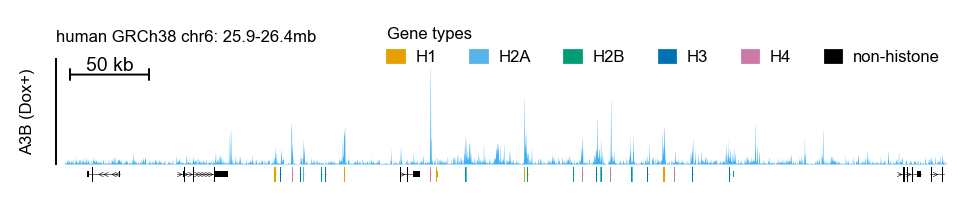

In [6]:
chrom = 'chr6'
start_pos = 25900000
end_pos = 26392000
# Replace path according to your own directory structure
bigwig_file = "/public4/home/jiangzj/data/tmp_node80/APOBEC3B-GSE148581-MCF10A/hg38-MCF10A-DOX+_A3B.logPvalue.bw"
region_name = f"human GRCh38 chr6: {start_pos/1e6:.1f}-{end_pos/1e6:.1f}mb"
y_label = "A3B (Dox+)"
gtf_file_dict = config_dict['human']
fig, axes = plt.subplots(2, 1, figsize=(5.8, 0.8), height_ratios=[14, 2], sharex=True)

# Adjust spacing
fig.subplots_adjust(hspace=0.05)
plot_bigwig_track(
    chrom, start_pos, end_pos,
    binsize=100,
    bigwig_file=bigwig_file,
    ax=axes[0],
    smoothing=False, smoothing_window=3, linewidth=0,
    color='#3FB0F3'
)
axes[0].spines[['top', 'right', 'bottom']].set_visible(False)
axes[0].xaxis.set_visible(False)
axes[0].set_title(
    region_name, loc='left'
)

ylim = axes[0].get_ylim()
axes[0].set_ylim(0, ylim[1])
# Annotate scale
scale_len = 50000
axes[0].annotate(
    "", 
    xy=(start_pos, ylim[1]*0.85), 
    xytext=(start_pos+scale_len, ylim[1]*0.85),
    arrowprops=dict(arrowstyle='|-|', lw=0.7, color='black', mutation_scale=2)
)
axes[0].text(start_pos+scale_len/2, ylim[1]*0.85, "50 kb", 
        fontsize=7, ha='center', va='bottom')
axes[0].set_ylabel(y_label)
axes[0].tick_params(axis='y', which='both', length=0) 
axes[0].set_yticklabels([])

for gene_type, gtffile in gtf_file_dict.items():
    plot_gtf(
            axes[1], gtffile,
            chrom, start_pos, end_pos, utr_rel_height=0.4,
            feature_order=['exon', 'CDS', 'UTR'], exon_color=color_dict[gene_type], intron_color=color_dict[gene_type], utr_color=color_dict[gene_type], arrow_head_length_propor=0.002
    )

unique_types = list(color_dict.keys())
handles = [
    mpatches.Patch(color=color_dict[gt], label=gt)
    for gt in unique_types
]
axes[0].legend(
    handles=handles,
    loc='upper right',    
    frameon=False,   
    fontsize=6,
    handlelength=1,    
    handletextpad=0.7,
    ncol=6,
    bbox_to_anchor=(1.0, 1.45),
    title='Gene types',
    alignment='left',
    title_fontsize=6,
)

Mouse RPA track (strand-specific)

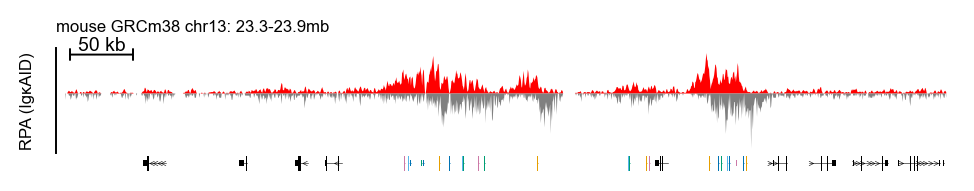

In [7]:
chrom = 'chr13'
start_pos = 23300000
end_pos = 23900000
treat = 'IgAID' # [AIDko, IgκAID]
region_name = f"mouse GRCm38 chr13: {start_pos/1e6:.1f}-{end_pos/1e6:.1f}mb"
y_label = f"RPA ({'IgκAID' if treat == 'IgAID' else 'AIDko'})"
gtf_file_dict = config_dict['mouse']
fig, axes = plt.subplots(2, 1, figsize=(5.8, 0.8), height_ratios=[14, 2], sharex=True)

# Adjust spacing
fig.subplots_adjust(hspace=0.05)

plot_bigwig_track(
    chrom, start_pos, end_pos,
    binsize=400,
    # Replace path according to your own directory structure
    bigwig_file=f"/public5/home/jiangzj/data/AID-related_seq/mouse/Yamane2013/53BPko-{treat}.plus.bw",
    ax=axes[0],
    smoothing=True, smoothing_window=3, linewidth=0,
    color='red', fill=True
)
plot_bigwig_track(
    chrom, start_pos, end_pos,
    binsize=400,
    # Replace path according to your own directory structure
    bigwig_file=f"/public5/home/jiangzj/data/AID-related_seq/mouse/Yamane2013/53BPko-{treat}.minus.bw",
    ax=axes[0],
    smoothing=False, smoothing_window=3, linewidth=0,
    color='gray',
    reverse=True, fill=True
)
axes[0].spines[['top', 'right', 'bottom']].set_visible(False)
axes[0].xaxis.set_visible(False)
axes[0].set_title(
    region_name, loc='left'
)

ylim = axes[0].get_ylim()
# axes[0].set_ylim(0, ylim[1])
# Annotate 5kb scale
axes[0].annotate(
    "", 
    xy=(start_pos, ylim[1]*0.85), 
    xytext=(start_pos+50000, ylim[1]*0.85),
    arrowprops=dict(arrowstyle='|-|', lw=0.7, color='black', mutation_scale=2)
)
axes[0].text(start_pos+25000, ylim[1]*0.85, "50 kb", 
        fontsize=7, ha='center', va='bottom')
axes[0].set_ylabel(y_label)
axes[0].tick_params(axis='y', which='both', length=0) 
axes[0].set_yticklabels([])

for gene_type, gtffile in gtf_file_dict.items():
    plot_gtf(
            axes[1], gtffile,
            chrom, start_pos, end_pos, utr_rel_height=0.4,
            feature_order=['exon', 'CDS', '5UTR', '3UTR'], exon_color=color_dict[gene_type], intron_color=color_dict[gene_type], utr_color=color_dict[gene_type], arrow_head_length_propor=0.002
    )

unique_types = list(color_dict.keys())
handles = [
    mpatches.Patch(color=color_dict[gt], label=gt)
    for gt in unique_types
]

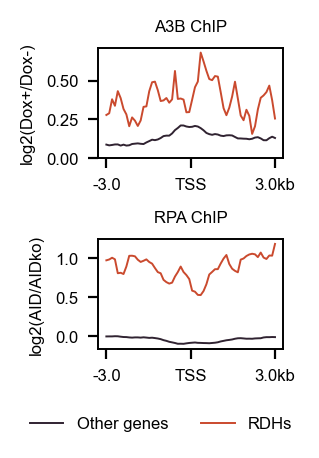

In [8]:
# Replace path according to your own directory structure
datasets_point_refer = [    
    ('human', 'A3B ChIP', 'log2(Dox+/Dox-)', False, 'hg38.IP-GFP_DMSO.DOX+vsDOX-.SES_log2.A3BeGFP_rp.binsize100'),
    ('mouse', 'RPA ChIP', 'log2(AID/AIDko)', False, '53BPko-AIDtg_vs_AIDko.SES_log2ratio.AID_rp.binsize100'),
]

row, col = 2, 1
fig, axes = plt.subplots(row, col, figsize=(1.5 * col, 1 * row))

custom_colors = ['#302331', "#CA4A2E", "#E88D2F", "#3BA595", '#3c6a70'] 
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=custom_colors)

for idx, (species, title, ylabel, inverty, file_suffix) in enumerate(datasets_point_refer):

    ax = axes[idx]
    filelist = [
        os.path.join(
            spe_basic_param[species]['base path'], prefix + '.' + file_suffix + '.matrix'
        ) for prefix in spe_basic_param[species]['prefix']
    ]
    namelist = ['All genes', 'Replication-dependent histone genes', 'Replication-independent histone genes']
    plot_deeptoolsop_subplot_reference_point(ax, filelist[0:2], namelist[0:2], title, ylabel, inverty, linewidth=0.7)

    ylim = ax.get_ylim()
    if ylim[0] > 0:
        ax.set_ylim(0, ylim[1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Other genes', 'RDHs'], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, frameon=False)
plt.tight_layout()